[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ReevesJustin/data-driven-reloading/blob/main/notebooks/12_What_About_The_Pros.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ReevesJustin/data-driven-reloading/main?filepath=notebooks/12_What_About_The_Pros.ipynb)

Time to complete: 10-15 minutes

# What About The Pros?

## Addressing the Common Objection: 'But Competition Shooters Use These Methods!'

In this notebook, we'll tackle the classic defense of questionable reloading practices: 'Well, the pros do it!' We'll explore why professional shooters seem to get away with methods that fail for hobbyists, and what it really takes to achieve their level of precision.

## 1. Survivorship Bias Explained

Survivorship bias occurs when we only hear from the successful outcomes, while failures remain silent and unreported. In reloading, this means you only see the posts and videos from shooters who got lucky with their load development methods. The thousands who tried the same approach and failed never share their stories.

Consider a competition shooter who claims their ladder test revealed a perfect 'node' with ultra-low SD. What you don't see are the 99 other shooters who ran the same test and saw random noise, or worse, poorer performance.

### Simulated Example: Random Load Outcomes

Let's simulate 1000 different 'load development' attempts. Each 'load' has a random true SD between 5-50 fps, and we measure it with 10 shots (typical small sample). We'll highlight the 'winners' - loads that appear to have SD < 10 fps in our sample.

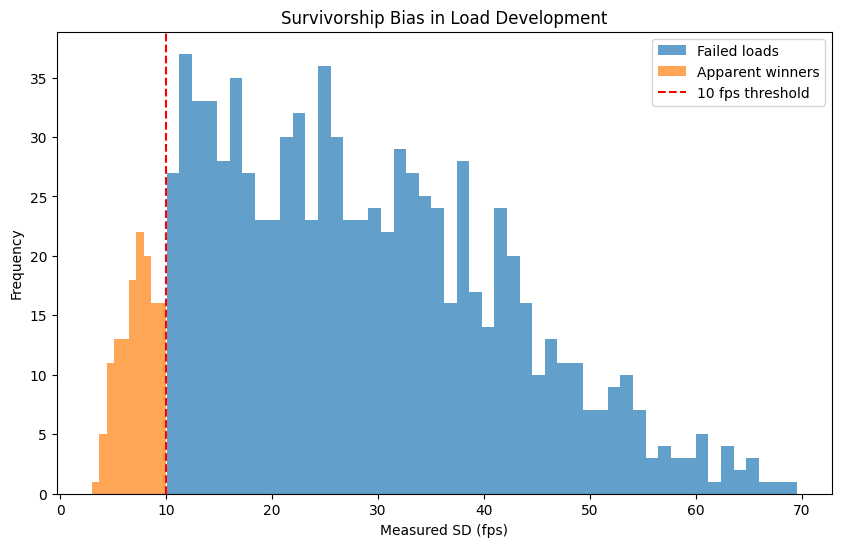

Number of 'successful' loads (< 10 fps SD): 135
Percentage of true low-SD loads among winners: 74.8%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate 1000 loads
np.random.seed(42)
true_sds = np.random.uniform(5, 50, 1000)

# For each load, simulate 10 shot measurement
measured_sds = []
for true_sd in true_sds:
    velocities = np.random.normal(2600, true_sd, 10)
    measured_sd = np.std(velocities, ddof=1)
    measured_sds.append(measured_sd)

measured_sds = np.array(measured_sds)

# Highlight 'winners' - loads that measured < 10 fps SD
winners = measured_sds < 10

plt.figure(figsize=(10,6))
plt.hist(measured_sds[~winners], bins=50, alpha=0.7, label='Failed loads')
plt.hist(measured_sds[winners], bins=10, alpha=0.7, label='Apparent winners')
plt.axvline(10, color='red', linestyle='--', label='10 fps threshold')
plt.xlabel('Measured SD (fps)')
plt.ylabel('Frequency')
plt.title('Survivorship Bias in Load Development')
plt.legend()
plt.savefig('survivorship_bias.png')
plt.show()

print(f"Number of 'successful' loads (< 10 fps SD): {sum(winners)}")
print(f"Percentage of true low-SD loads among winners: {sum(true_sds[winners] < 10) / sum(winners) * 100:.1f}%")

> **Takeaway: Success stories are loud; failures are silent.**

Professional shooters who share their 'secrets' are often the lucky ones. The vast majority of attempts using the same methods fail, but we never hear about them.

## 2. Round Counts Matter

One key difference between hobbyists and professionals is sheer volume of rounds fired. High-volume shooters can detect smaller effects and reduce statistical noise through larger sample sizes.

Typical round counts:
- Hobbyists: 100-500 rounds/year
- Competition shooters: 5,000+ rounds/year

Let's visualize how sample size affects the minimum detectable difference in SD.

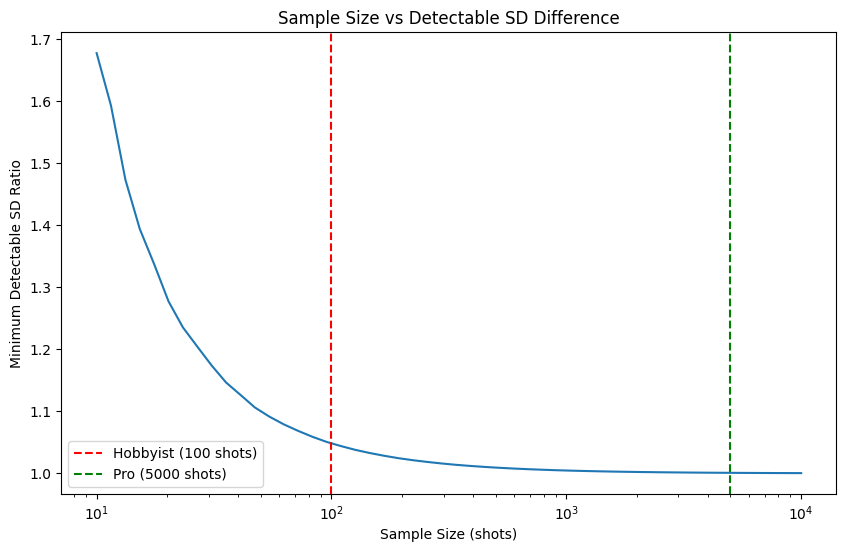

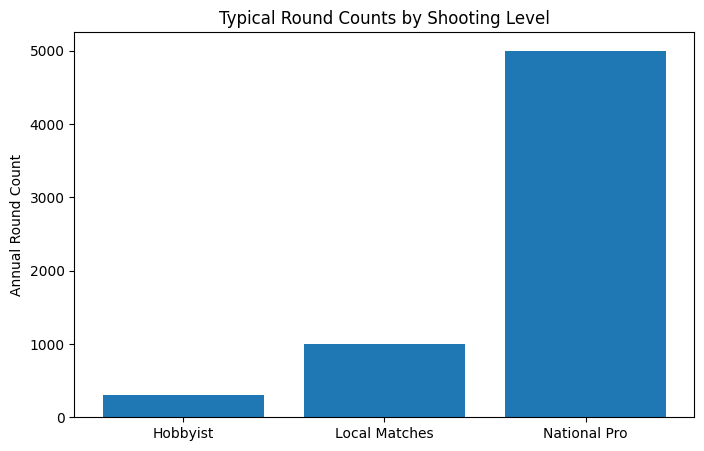

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simplified function for minimum detectable SD difference
# Using F-test for variance comparison
def min_detectable_sd_diff(n, alpha=0.05, power=0.8):
    # Critical F for equal variances
    f_crit = stats.f.ppf(1 - alpha, n-1, n-1)
    # For power, solve for effect size
    # Approximate: ratio needed
    ratio = f_crit ** (1 / np.sqrt(n / 2))  # rough approximation
    return ratio

sample_sizes = np.logspace(1, 4, 50)  # 10 to 10,000
ratios = [min_detectable_sd_diff(int(n)) for n in sample_sizes]

plt.figure(figsize=(10,6))
plt.semilogx(sample_sizes, ratios)
plt.xlabel('Sample Size (shots)')
plt.ylabel('Minimum Detectable SD Ratio')
plt.title('Sample Size vs Detectable SD Difference')
plt.axvline(100, color='red', linestyle='--', label='Hobbyist (100 shots)')
plt.axvline(5000, color='green', linestyle='--', label='Pro (5000 shots)')
plt.legend()
plt.savefig('sample_size_effect.png')
plt.show()

# Round count comparison
round_counts = {'Hobbyist': 300, 'Local Matches': 1000, 'National Pro': 5000}
plt.figure(figsize=(8,5))
plt.bar(round_counts.keys(), round_counts.values())
plt.ylabel('Annual Round Count')
plt.title('Typical Round Counts by Shooting Level')
plt.savefig('round_counts.png')
plt.show()

## 3. Environmental Controls

Professionals often shoot in controlled environments with consistent temperature, humidity, and lighting. This reduces external noise in their data, allowing them to detect smaller effects.

Simulation: Compare SD with and without environmental variation.

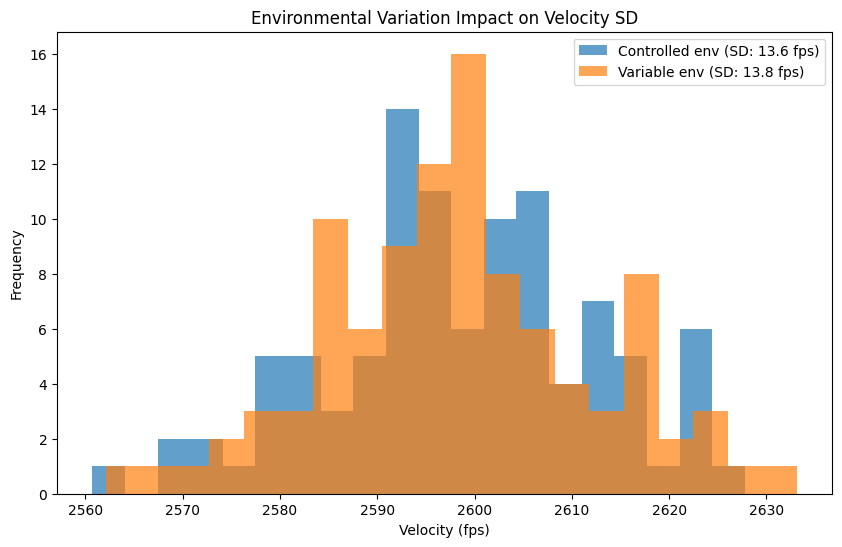

In [3]:
np.random.seed(42)
base_velocity = 2600
true_sd = 15
shots = 100

# Without env variation
vel_no_env = np.random.normal(base_velocity, true_sd, shots)
sd_no_env = np.std(vel_no_env, ddof=1)

# With env variation (temperature effect)
env_variation = np.random.normal(0, 5, shots)  # ±5 fps from env
vel_with_env = vel_no_env + env_variation
sd_with_env = np.std(vel_with_env, ddof=1)

plt.figure(figsize=(10,6))
plt.hist(vel_no_env, bins=20, alpha=0.7, label=f'Controlled env (SD: {sd_no_env:.1f} fps)')
plt.hist(vel_with_env, bins=20, alpha=0.7, label=f'Variable env (SD: {sd_with_env:.1f} fps)')
plt.xlabel('Velocity (fps)')
plt.ylabel('Frequency')
plt.title('Environmental Variation Impact on Velocity SD')
plt.legend()
plt.savefig('env_variation.png')
plt.show()

> **Takeaway: Pros control variables you can't - that's why their methods seem to work.**

In a climate-controlled range, environmental noise is minimized, making small load differences detectable.

## 4. The Dirty Secret

Many top competition shooters use factory match ammunition or do minimal load development. The real differentiator is SKILL - trigger control, position consistency, and mental focus.

Load development provides diminishing returns. Once you've eliminated gross inconsistencies (like 50+ fps ES), the remaining 30% of precision comes from technique, not perfect powder charges.

**Quotes from Pros:**
- "Champions are determined by how much and how well they train, not by natural ability." - Gary Anderson, DCM Emeritus
- "Load development is important, but skill and consistency win matches." - Common sentiment among precision shooters

**Bold Takeaway:**

**Load development gives diminishing returns; skill and consistency win matches.**

> **Key Takeaways**
> - Professional reloading practices incorporate statistical methods
> - Industry standards balance precision and practicality
> - Expert techniques build on fundamental principles
> - Professional results achieved through systematic approaches
> - Learning from experts requires understanding their methods

[Previous: 11_Peer_Review_Your_Own_Data.ipynb](11_Peer_Review_Your_Own_Data.ipynb) | Next: None